# Réduire les accidents de la route — pipeline d'aide à la décision pour une agence de voirie

**Rôle incarné :** agence de voirie / DOT d'une collectivité territoriale (gestionnaire d'infrastructure routière).
**Données :** *US Accidents* (Feb 2016 → Mar 2023, ~7,73 M accidents, 49 États).

---

## Le problème métier

> *« Comment réduire durablement les accidents sur notre réseau, avec un budget de travaux limité ? »*

Un DOT ne peut pas tout rénover. Il doit décider **où** intervenir et **quoi** y faire. Aujourd'hui cette
priorisation est surtout réactive (remontées terrain, accidents médiatisés). On apporte une priorisation
**data-driven et explicable**. On décline le fil rouge en trois questions :

| Question métier | Traduction data | Nature |
|---|---|---|
| **OÙ** rénover en priorité ? | Classement des zones par risque, **normalisé par l'exposition** routière | Agrégation géospatiale (descriptif) |
| **QUOI** installer sur place ? | Quels éléments d'infra aggravent → **modèle de gravité interprété** | ML supervisé *(moteur de preuve)* |
| **QUAND** activer des mesures temporaires ? | Patterns temporels / météo du risque | Visualisation descriptive |

## Le principe méthodologique clé : le modèle comme *moteur de preuve*

On **n'a pas** pour objectif de livrer un prédicteur de gravité. Notre but est de **corriger** le problème.
Mais pour savoir *quoi* corriger, on entraîne un modèle qui prédit la gravité d'un accident à partir de
l'infrastructure et du contexte, **puis on l'interroge** (importances de variables, valeurs SHAP) pour
identifier *quels éléments structurels sont associés à des accidents plus graves*.

> **La prédiction est le moyen ; l'explication est le livrable.** Ce détour se justifie : il fournit une
> tâche supervisée *évaluable* (on peut comparer plusieurs modèles), il *contrôle les confondants*
> (météo/heure mis comme variables de contrôle), et il évite la **tautologie** d'un modèle qui prédirait une
> quantité à partir de ses propres composantes.

**Ce qu'on ne prétend pas :** prouver une causalité. Sans panel avant/après installation d'équipement, nos
résultats sont des **associations / signaux de priorisation**, pas des preuves d'efficacité. (cf. § *Limites*.)

## Architecture de la pipeline

```
Setup → Chargement (schéma explicite) → NETTOYAGE explicite
   ├─ A. EDA / Visualisation (volumétrie, biais, sévérité, "QUAND")
   ├─ B. OÙ  : scoring H3 + exposition OSM → zones prioritaires
   ├─ C. QUOI: modèle de gravité (baseline→logreg→arbre→RF→GBT) → SHAP → leviers
   ├─ D. Synthèse décisionnelle (par zone : où + quoi + impact estimé)
   └─ E. Analyse critique & recul
```

Le notebook s'exécute **de bout en bout sans intervention** (*Run All*). Les données sont téléchargées
automatiquement, les graines aléatoires sont fixées, et le nettoyage est **défensif** : il fonctionne sur
n'importe quel sous-ensemble du dataset (n'importe quel État, n'importe quelle période).

## 0 — Setup & reproductibilité

On fixe l'environnement pour que **n'importe qui obtienne le même résultat**. Toutes les dépendances sont
dans `requirements.txt` (versions figées). Les constantes de la pipeline sont **rassemblées ici** et nommées :
changer `STATE` suffit à rejouer toute l'analyse sur un autre territoire → c'est notre preuve de **généricité**.

In [1]:
# Installe les dépendances (idempotent). Décommenter si l'environnement n'est pas déjà prêt.
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /Users/saba/Prog/Epita/ING2/xPloring/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, warnings, math, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Graines : reproductibilité ---
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# --- Constantes de pipeline (tout est paramétrable et documenté ici) ---
STATE          = "CA"     # territoire de démonstration ; changer suffit à rejouer ailleurs
H3_RES         = 8        # ~0,7 km² : l'échelle d'un carrefour
PRIORITY_N     = 50       # nb de zones prioritaires retenues
LIFT_MIN       = 1.5      # seuil de sur-représentation pour attribuer un aléa à une zone
PRESENCE_MIN   = 0.05     # un équipement est "présent" s'il touche >= 5% des accidents de la zone
MIN_N          = 200      # taille mini d'échantillon pour un effet conditionnel fiable
GRAVE_THRESHOLD = 3       # sévérité >= 3 => accident "grave" (cible binaire)
MAX_MODEL_ROWS = 800_000  # plafond de lignes pour la comparaison de modèles (compromis repro/coût ; None = tout)
RUN_OSM_EXPOSURE = True    # exposition routière OSM (réseau requis) ; bascule à False si hors-ligne
SHAP_SAMPLE    = 5_000    # nb de lignes pour le calcul SHAP (TreeExplainer ne scale pas à des millions)

print("Config :", dict(STATE=STATE, H3_RES=H3_RES, PRIORITY_N=PRIORITY_N,
                        GRAVE_THRESHOLD=GRAVE_THRESHOLD, MAX_MODEL_ROWS=MAX_MODEL_ROWS))

Config : {'STATE': 'CA', 'H3_RES': 8, 'PRIORITY_N': 50, 'GRAVE_THRESHOLD': 3, 'MAX_MODEL_ROWS': 800000}


**Pourquoi PySpark ?** Le dataset fait 7,73 M lignes : pandas pur saturerait la mémoire pour les étapes
globales (chargement, agrégation US). Spark traite ce volume en local (`local[*]`) et scalerait vers un
cluster sans changer le code. On bascule en pandas/scikit-learn **seulement** quand le volume est réduit
(agrégats par zone, échantillon de modélisation).

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, StringType, IntegerType,
                               DoubleType, BooleanType, TimestampType)

spark = (SparkSession.builder
         .master("local[*]").appName("voirie_reduction_accidents")
         .config("spark.driver.memory", "6g")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/22 16:53:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1


On gère la compatibilité **h3 v3/v4** une seule fois (factorisation : ces helpers sont réutilisés
partout dans le notebook, jamais recopiés).

In [4]:
import h3
try:
    h3.latlng_to_cell(0.0, 0.0, H3_RES)            # API v4
    h3_encode   = lambda lat, lng: h3.latlng_to_cell(lat, lng, H3_RES)
    h3_boundary = lambda c: h3.cell_to_boundary(c)
    h3_center   = lambda c: h3.cell_to_latlng(c)
except AttributeError:                              # API v3
    h3_encode   = lambda lat, lng: h3.geo_to_h3(lat, lng, H3_RES)
    h3_boundary = lambda c: h3.h3_to_geo_boundary(c)
    h3_center   = lambda c: h3.h3_to_geo(c)
print("h3", h3.__version__)

h3 4.4.2


## 1 — Chargement (reproductible, schéma explicite)

Données chargées **automatiquement** via `kagglehub` (repli sur un CSV local s'il existe). On déclare un
**schéma explicite** plutôt que `inferSchema` : (1) reproductibilité — les types ne dépendent pas d'un
échantillon lu au hasard ; (2) performance — on évite une passe de lecture supplémentaire.

In [5]:
LOCAL_CANDIDATES = [
    "US_Accidents_March23.csv", "../US_Accidents_March23.csv",
    os.path.expanduser("~/Prog/Epita/ING2/xPloring/US_Accidents_March23.csv"),
]
CSV_PATH = next((p for p in LOCAL_CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    import kagglehub
    path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
    csvs = [f for f in os.listdir(path) if f.endswith(".csv")]
    assert csvs, "Aucun CSV dans le répertoire KaggleHub."
    CSV_PATH = os.path.join(path, csvs[0])
print("CSV utilisé :", CSV_PATH)

CSV utilisé : /Users/saba/Prog/Epita/ING2/xPloring/US_Accidents_March23.csv


In [6]:
schema = StructType([
    StructField("ID", StringType()), StructField("Source", StringType()),
    StructField("Severity", IntegerType()),
    StructField("Start_Time", TimestampType()), StructField("End_Time", TimestampType()),
    StructField("Start_Lat", DoubleType()), StructField("Start_Lng", DoubleType()),
    StructField("End_Lat", DoubleType()), StructField("End_Lng", DoubleType()),
    StructField("Distance(mi)", DoubleType()), StructField("Description", StringType()),
    StructField("Street", StringType()), StructField("City", StringType()),
    StructField("County", StringType()), StructField("State", StringType()),
    StructField("Zipcode", StringType()), StructField("Country", StringType()),
    StructField("Timezone", StringType()), StructField("Airport_Code", StringType()),
    StructField("Weather_Timestamp", TimestampType()),
    StructField("Temperature(F)", DoubleType()), StructField("Wind_Chill(F)", DoubleType()),
    StructField("Humidity(%)", DoubleType()), StructField("Pressure(in)", DoubleType()),
    StructField("Visibility(mi)", DoubleType()), StructField("Wind_Direction", StringType()),
    StructField("Wind_Speed(mph)", DoubleType()), StructField("Precipitation(in)", DoubleType()),
    StructField("Weather_Condition", StringType()),
    StructField("Amenity", BooleanType()), StructField("Bump", BooleanType()),
    StructField("Crossing", BooleanType()), StructField("Give_Way", BooleanType()),
    StructField("Junction", BooleanType()), StructField("No_Exit", BooleanType()),
    StructField("Railway", BooleanType()), StructField("Roundabout", BooleanType()),
    StructField("Station", BooleanType()), StructField("Stop", BooleanType()),
    StructField("Traffic_Calming", BooleanType()), StructField("Traffic_Signal", BooleanType()),
    StructField("Turning_Loop", BooleanType()), StructField("Sunrise_Sunset", StringType()),
    StructField("Civil_Twilight", StringType()), StructField("Nautical_Twilight", StringType()),
    StructField("Astronomical_Twilight", StringType()),
])
raw = spark.read.option("header", True).schema(schema).csv(CSV_PATH)
# snake_case : '(', ')', '%' -> séparateurs propres
raw = raw.toDF(*[c.lower().replace("(", "_").replace(")", "").replace("%", "pct") for c in raw.columns])
print("Lignes :", f"{raw.count():,}", "| colonnes :", len(raw.columns))

Lignes : 7,728,394 | colonnes : 46


## 2 — Nettoyage & prétraitement (explicite, défensif, justifié)

> Exigence du projet : **rien de caché**. Pour chaque décision : *quoi* + *pourquoi*. Le nettoyage est
> écrit comme **une fonction unique** appliquée à n'importe quel sous-ensemble (n'importe quel État/période),
> ce qui garantit que la pipeline « rend viables » des données brutes quelconques du dataset.

**Décisions de nettoyage et leurs raisons :**

| Élément | Décision | Pourquoi |
|---|---|---|
| `end_lat`, `end_lng` (~44 % NA) | **abandonnés** | Trop manquants ; on travaille sur le point de départ `start_lat/lng`. |
| `wind_chill_f` (~26 % NA) | **supprimé** | Redondant avec `temperature_f`. |
| Météo numérique (NA résiduels) | **imputation médiane** | Robuste aux valeurs extrêmes ; conserve l'échantillon. |
| `weather_condition` (texte libre, ~100 modalités) | **regroupé** en 6 buckets | Évite l'explosion de variables ; modalités lisibles (Clear/Cloud/Rain/Snow/Fog/Other). |
| Lignes sans `severity`/`start_lat`/`start_lng` | **supprimées** | Inutilisables (cible ou localisation absente). |
| Booléens d'infra NA | **`False`** | NA = équipement non signalé ⇒ traité comme absent. |
| `severity ∈ {1..4}` | **binarisé** `grave = severity ≥ 3` | Classe 2 ≈ 80 % : le multiclasse rendrait métriques et message illisibles. |
| `turning_loop` | **exclu** des features | Quasi constant ⇒ aucun pouvoir discriminant. |

On dérive aussi des **variables temporelles** (`hour`, `dow`, `month`, `is_night`) : elles servent au volet
« QUAND » (visu) et de **variables de contrôle** dans le modèle.

In [7]:
INFRA = ["junction", "crossing", "stop", "traffic_signal", "railway", "station",
         "roundabout", "bump", "give_way", "no_exit", "traffic_calming", "amenity"]
WEATHER_NUM = ["temperature_f", "humidity_pct", "visibility_mi", "wind_speed_mph", "pressure_in"]

def bucket_weather(col):
    # Regroupe le texte libre météo en 6 familles lisibles (défensif : NULL -> 'Other').
    c = F.lower(F.coalesce(col, F.lit("")))
    return (F.when(c.contains("snow") | c.contains("sleet") | c.contains("wintry") | c.contains("ice"), "Snow")
             .when(c.contains("rain") | c.contains("drizzle") | c.contains("shower") | c.contains("thunder"), "Rain")
             .when(c.contains("fog") | c.contains("mist") | c.contains("haze"), "Fog")
             .when(c.contains("cloud") | c.contains("overcast"), "Cloud")
             .when(c.contains("clear") | c.contains("fair"), "Clear")
             .otherwise("Other"))

def clean(df):
    # Nettoyage défensif appliqué à n'importe quel sous-ensemble du dataset.
    df = df.drop("end_lat", "end_lng", "wind_chill_f")            # trop de NA / redondant
    df = df.dropna(subset=["severity", "start_lat", "start_lng"]) # cible & localisation requises
    # cible binaire
    df = df.withColumn("grave", (F.col("severity") >= F.lit(GRAVE_THRESHOLD)).cast("int"))
    # dérivées temporelles
    df = (df.withColumn("hour", F.hour("start_time"))
            .withColumn("dow", F.dayofweek("start_time"))
            .withColumn("month", F.month("start_time"))
            .withColumn("year", F.year("start_time"))
            .withColumn("is_night", (F.col("sunrise_sunset") == F.lit("Night")).cast("int")))
    # météo regroupée + booléens infra -> 0/1 (NA = absent)
    df = df.withColumn("weather_bucket", bucket_weather(F.col("weather_condition")))
    for c in INFRA:
        df = df.withColumn(c, F.coalesce(F.col(c), F.lit(False)).cast("int"))
    for c in ["hour", "is_night"]:
        df = df.withColumn(c, F.coalesce(F.col(c), F.lit(0)))
    return df

clean_df = clean(raw).cache()
n_clean = clean_df.count()
print(f"Après nettoyage : {n_clean:,} lignes")
print("Taux d'accidents graves (cible) :",
      f"{clean_df.agg(F.mean('grave')).first()[0]*100:.1f} %  -> classe déséquilibrée, à gérer (§C)")

26/06/22 16:54:00 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Après nettoyage : 7,728,394 lignes


Taux d'accidents graves (cible) : 19.5 %  -> classe déséquilibrée, à gérer (§C)


### Tests & garde-fous — *protocole de validation du livrable*

Le livrable est **garanti par des tests** : on vérifie ici les invariants du nettoyage (cible binaire, absence de nulls critiques, types). Plus loin (partie C) on ajoute des **tests anti-fuite**. Une assertion qui échoue **stoppe** le notebook → on ne livre jamais de résultats sur des données mal préparées.

In [8]:
def check(name, cond):
    assert cond, f"ECHEC test : {name}"
    print(f"  OK - {name}")

print("Tests d'intégrité après nettoyage :")
check("cible 'grave' binaire {0,1}",
      {r["grave"] for r in clean_df.select("grave").distinct().collect()} <= {0, 1})
check("aucune coordonnée nulle (start_lat/lng)",
      clean_df.filter(F.col("start_lat").isNull() | F.col("start_lng").isNull()).count() == 0)
check("aucune sévérité nulle",
      clean_df.filter(F.col("severity").isNull()).count() == 0)
check("colonnes trop manquantes supprimées (end_lat/lng, wind_chill)",
      all(c not in clean_df.columns for c in ["end_lat", "end_lng", "wind_chill_f"]))
_mm = clean_df.agg(*[F.min(c).alias(c + "_mn") for c in INFRA],
                   *[F.max(c).alias(c + "_mx") for c in INFRA]).first()
check("booléens d'infra réduits à {0,1}",
      all(_mm[c + "_mn"] in (0, 1) and _mm[c + "_mx"] in (0, 1) for c in INFRA))
check("dérivées temporelles présentes",
      all(c in clean_df.columns for c in ["hour", "dow", "month", "year", "is_night"]))
print("-> Tous les tests de nettoyage passent.")

Tests d'intégrité après nettoyage :


  OK - cible 'grave' binaire {0,1}
  OK - aucune coordonnée nulle (start_lat/lng)
  OK - aucune sévérité nulle
  OK - colonnes trop manquantes supprimées (end_lat/lng, wind_chill)


  OK - booléens d'infra réduits à {0,1}
  OK - dérivées temporelles présentes
-> Tous les tests de nettoyage passent.


## A — Exploration & visualisation (dont « QUAND »)

Chaque visualisation répond à une **question métier** précise (pas de décor). On met aussi en avant les
résultats **contre-intuitifs** : ce sont eux qui créent de la valeur par rapport au *common knowledge*.

### A.0 Valeurs manquantes — *« quoi nettoyer, et pourquoi ? »*

Avant toute analyse, on mesure les manques sur les données **brutes**. Ce graphe **justifie visuellement** les décisions de nettoyage (colonnes abandonnées, imputations) prises en partie 2.

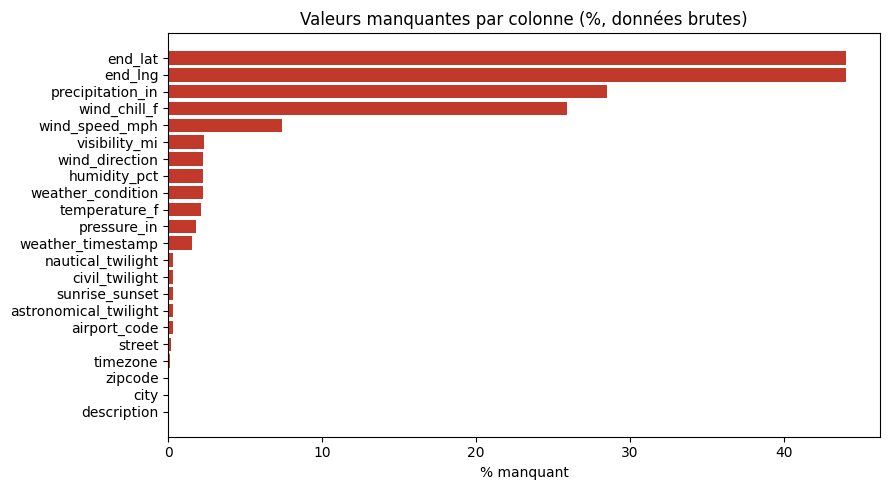

end_lat                  44.0
end_lng                  44.0
precipitation_in         28.5
wind_chill_f             25.9
wind_speed_mph            7.4
visibility_mi             2.3
wind_direction            2.3
humidity_pct              2.3
weather_condition         2.2
temperature_f             2.1
pressure_in               1.8
weather_timestamp         1.6
nautical_twilight         0.3
civil_twilight            0.3
sunrise_sunset            0.3
astronomical_twilight     0.3
airport_code              0.3
street                    0.1
timezone                  0.1
zipcode                   0.0
city                      0.0
description               0.0


In [9]:
# % de valeurs manquantes par colonne, sur les données BRUTES (avant nettoyage)
na = (raw.select([F.mean(F.col(c).isNull().cast("double")).alias(c) for c in raw.columns])
        .toPandas().T)
na = (na[0] * 100).sort_values(ascending=False)
na = na[na > 0]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(na.index[::-1], na.values[::-1], color="#c0392b")
ax.set_title("Valeurs manquantes par colonne (%, données brutes)")
ax.set_xlabel("% manquant"); plt.tight_layout(); plt.show()
print(na.round(1).to_string())

### A.1 Couverture & biais — *« peut-on faire confiance à ces données partout ? »*

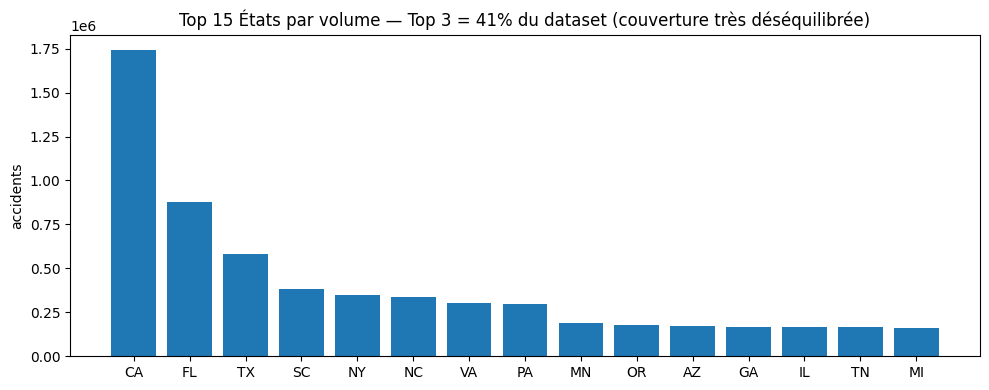

In [10]:
by_state = (clean_df.groupBy("state").count().orderBy(F.desc("count"))
            .limit(15).toPandas())
tot = clean_df.count()
top3 = by_state["count"].head(3).sum() / tot * 100
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_state["state"], by_state["count"])
ax.set_title(f"Top 15 États par volume — Top 3 = {top3:.0f}% du dataset (couverture très déséquilibrée)")
ax.set_ylabel("accidents"); plt.tight_layout(); plt.show()

**Lecture :** la couverture est très inégale (Top 3 ≈ 41 %). Conséquence assumée (*biais de reporting*
MapQuest/Bing) : *peu de lignes ≠ peu d'accidents*. On ne compare donc pas les États entre eux ; on raisonne
**à l'intérieur d'un territoire** (d'où l'analyse « OÙ » paramétrée par `STATE`).

### A.2 Distribution de la sévérité — *« justifie la binarisation »*

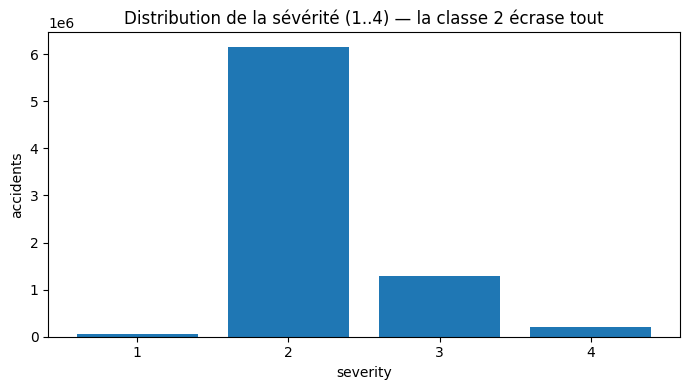

   severity    count   pct
0         1    67366   0.9
1         2  6156981  79.7
2         3  1299337  16.8
3         4   204710   2.6


In [11]:
sev = clean_df.groupBy("severity").count().orderBy("severity").toPandas()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sev["severity"].astype(str), sev["count"])
ax.set_title("Distribution de la sévérité (1..4) — la classe 2 écrase tout")
ax.set_xlabel("severity"); ax.set_ylabel("accidents"); plt.tight_layout(); plt.show()
print((sev.assign(pct=lambda d: (d["count"]/d["count"].sum()*100).round(1))))

**Lecture :** la sévérité 2 domine (~80 %). Une classification 1–4 produirait des métriques illisibles
et un message flou. On **binarise** (`grave = sévérité ≥ 3`), ce qui donne une cible nette et une métrique
interprétable côté décideur (« grave / non grave »).

### A.2bis Sévérité selon l'infrastructure — *« quels éléments accompagnent les accidents graves ? »*

Premier signal **descriptif** (avant tout modèle) : on compare la sévérité moyenne *en présence* vs *en absence* de chaque élément. C'est une **comparaison non triviale** qui annonce les leviers — et qu'on **confrontera** plus tard aux contributions SHAP du modèle (convergence descriptif ↔ modèle = robustesse).

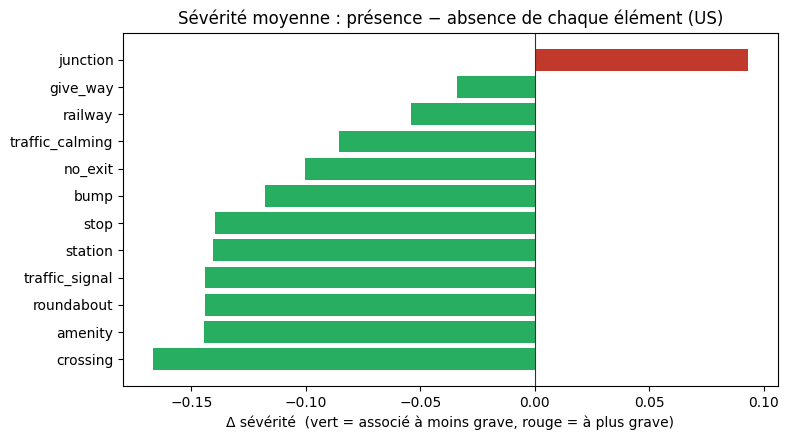

          infra  sev_sans  sev_avec  delta
       crossing     2.231     2.064 -0.167
        amenity     2.214     2.070 -0.144
     roundabout     2.212     2.068 -0.144
 traffic_signal     2.234     2.090 -0.144
        station     2.216     2.075 -0.141
           stop     2.216     2.076 -0.140
           bump     2.212     2.094 -0.118
        no_exit     2.213     2.112 -0.100
traffic_calming     2.212     2.127 -0.086
        railway     2.213     2.159 -0.054
       give_way     2.213     2.179 -0.034
       junction     2.206     2.298  0.093


In [12]:
# Sévérité moyenne avec / sans chaque élément d'infra — en UN seul passage Spark
exprs = []
for c in INFRA:
    exprs.append(F.mean(F.when(F.col(c) == 1, F.col("severity"))).alias(c + "__a"))
    exprs.append(F.mean(F.when(F.col(c) == 0, F.col("severity"))).alias(c + "__s"))
agg = clean_df.agg(*exprs).toPandas().iloc[0]
rows = [{"infra": c, "sev_sans": agg[c + "__s"], "sev_avec": agg[c + "__a"],
         "delta": (agg[c + "__a"] - agg[c + "__s"])} for c in INFRA]
dlt = pd.DataFrame(rows).dropna().sort_values("delta")
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#27ae60" if v < 0 else "#c0392b" for v in dlt["delta"]]
ax.barh(dlt["infra"], dlt["delta"], color=colors)
ax.axvline(0, color="#333", lw=0.8)
ax.set_title("Sévérité moyenne : présence − absence de chaque élément (US)")
ax.set_xlabel("Δ sévérité  (vert = associé à moins grave, rouge = à plus grave)")
plt.tight_layout(); plt.show()
print(dlt.round(3).to_string(index=False))

### A.3 « QUAND » — patterns temporels & météo (pour les mesures dynamiques)

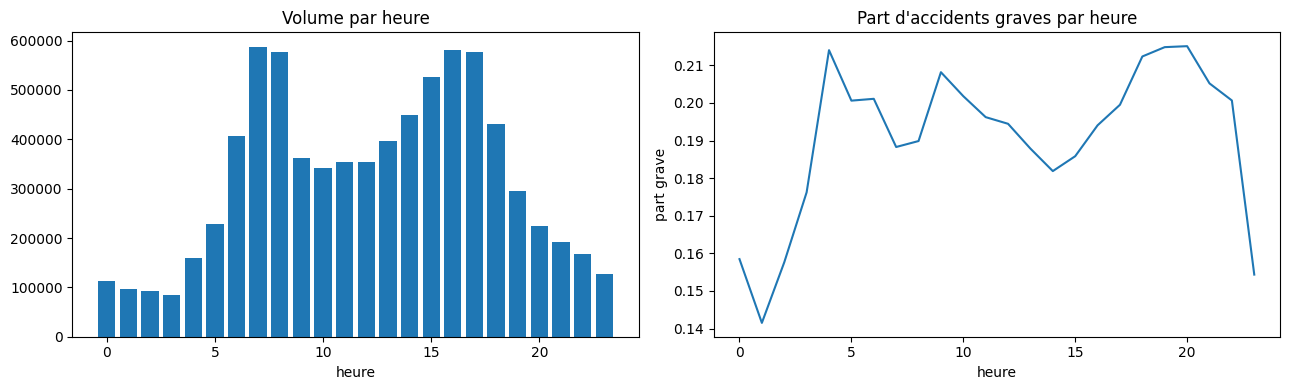

In [13]:
hourly = clean_df.groupBy("hour").agg(F.count("*").alias("n"),
                                       F.mean("grave").alias("part_grave")).orderBy("hour").toPandas()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(hourly["hour"], hourly["n"]);          ax[0].set_title("Volume par heure"); ax[0].set_xlabel("heure")
ax[1].plot(hourly["hour"], hourly["part_grave"]); ax[1].set_title("Part d'accidents graves par heure")
ax[1].set_xlabel("heure"); ax[1].set_ylabel("part grave"); plt.tight_layout(); plt.show()

In [14]:
wx = (clean_df.groupBy("weather_bucket")
      .agg(F.count("*").alias("n"), F.mean("grave").alias("part_grave"))
      .orderBy(F.desc("n")).toPandas())
print("Sévérité par condition météo (regroupée) :")
print(wx.assign(part_grave=lambda d: (d["part_grave"]*100).round(1)))

Sévérité par condition météo (regroupée) :
  weather_bucket        n  part_grave
0          Clear  3405216        16.9
1          Cloud  3163750        21.7
2           Rain   577214        23.0
3          Other   218852        21.0
4            Fog   189635        16.1
5           Snow   173727        19.5


**Lecture (« QUAND ») :** le risque varie surtout par **heure** (pics aux heures de pointe). Côté **météo**, le résultat est nuancé et en partie **contre-intuitif** : la part d'accidents graves reste dans une fourchette étroite (~16–23 %), et c'est le **brouillard** qui affiche la part la **plus basse** (≈16 %, comme le temps clair) — sans doute parce qu'on y conduit plus prudemment — tandis que pluie et ciel couvert sont un cran au-dessus (~22–23 %). Aucune condition ne domine nettement la *gravité* : la météo est un facteur **conjoncturel** (modulation faible), pas un levier structurel. Ces signaux nourrissent d'éventuelles **mesures dynamiques** (panneaux à messages variables), pas la rénovation — on les **visualise**, on ne les met pas au cœur du modèle.

### A.4 « QUAND » — jours fériés & grands événements

Le risque conjoncturel se lit aussi sur le calendrier. Résultat souvent **contre-intuitif** : la sévérité **ne s'emballe pas** systématiquement pendant les fêtes — un signal utile pour calibrer (ou non) des mesures dynamiques.

In [15]:
# Sévérité / volume pendant des fenêtres calendaires marquantes (vs période normale)
mo, dy = F.month("start_time"), F.dayofmonth("start_time")
ev = (F.when(((mo == 12) & (dy >= 24)) | ((mo == 1) & (dy <= 2)), "Noël / Nouvel An")
        .when((mo == 11) & (dy >= 22) & (dy <= 28), "Sem. Thanksgiving")
        .when((mo == 7) & (dy >= 3) & (dy <= 5), "4 Juillet")
        .when((mo == 5) & (dy >= 25), "Memorial Day (approx.)")
        .otherwise("Période normale"))
evt = (clean_df.withColumn("event", ev)
       .groupBy("event").agg(F.count("*").alias("n"),
                             F.mean("grave").alias("part_grave"),
                             F.mean("severity").alias("sev_moy"))
       .orderBy(F.desc("n")).toPandas())
evt["part_grave"] = (evt["part_grave"] * 100).round(1)
evt["sev_moy"] = evt["sev_moy"].round(3)
print("Sévérité par fenêtre calendaire (part_grave en %) :")
print(evt.to_string(index=False))

Sévérité par fenêtre calendaire (part_grave en %) :
                 event       n  part_grave  sev_moy
       Période normale 7203628        19.5    2.213
      Noël / Nouvel An  216853        15.5    2.182
     Sem. Thanksgiving  140718        19.3    2.216
Memorial Day (approx.)  124556        21.1    2.216
             4 Juillet   42639        23.2    2.249


## B — OÙ rénover en priorité (scoring géospatial + exposition)

L'unité d'analyse n'est plus l'accident mais la **zone** (cellule H3, rés. 8, **équi-surface** → un comptage
est déjà une densité comparable). On classe les zones d'un territoire (`STATE`) par leur **charge
d'accidents pondérée par la gravité**, puis on **normalise par l'exposition routière** pour distinguer
« vraiment dangereux » de « simplement très fréquenté ».

- **Pourquoi pondérer par la gravité ?** 100 accidents légers ≠ 100 accidents graves.
- **Pourquoi filtrer par le volume et non la gravité seule ?** un fort volume au même endroit = problème
  *structurel* (géométrie, équipement) ; un accident grave isolé = *erreur humaine ponctuelle*, hors levier DOT.

In [16]:
# On ramène le territoire choisi en pandas (volume réduit : ~1,7 M pour la CA)
terr = (clean_df.filter(F.col("state") == STATE)
        .select("start_lat", "start_lng", "severity", "grave", "year", *INFRA)).toPandas()
terr["h3_cell"] = [h3_encode(a, b) for a, b in zip(terr["start_lat"], terr["start_lng"])]
print(f"{STATE} : {len(terr):,} accidents, {terr['h3_cell'].nunique():,} cellules H3")

CA : 1,741,433 accidents, 58,857 cellules H3


In [17]:
# Agrégation par zone, pondérée gravité (charge = somme des sévérités).
for el in INFRA:
    terr["sev_" + el] = terr["severity"] * terr[el]
aggmap = {"severity": ["count", "mean", "sum"]}
for el in INFRA:
    aggmap[el] = "sum"; aggmap["sev_" + el] = "sum"
zone = terr.groupby("h3_cell").agg(aggmap)
zone.columns = ["n_accidents", "avg_severity", "charge"] + \
               [c for el in INFRA for c in ("n_" + el, "charge_" + el)]
zone = zone.reset_index().sort_values("charge", ascending=False).reset_index(drop=True)
zone["rank"] = zone.index + 1
priority = zone.head(PRIORITY_N).copy()
print(f"{len(zone):,} zones agrégées — top {PRIORITY_N} retenu comme prioritaire (par charge)")
priority[["rank", "n_accidents", "avg_severity", "charge"]].head(8)

58,857 zones agrégées — top 50 retenu comme prioritaire (par charge)


,rank,n_accidents,avg_severity,charge
0,1,2861,2.529186,7236
1,2,2543,2.497051,6350
2,3,2431,2.327437,5658
3,4,2174,2.576357,5601
4,5,2127,2.543018,5409
5,6,2163,2.472492,5348
6,7,2201,2.417537,5321
7,8,2323,2.049074,4760


### B.1 Exposition routière (OSM) — *« dangereux, ou juste fréquenté ? »*

On télécharge, pour chaque zone prioritaire, la **longueur de réseau routier** (OSM via `osmnx`) contenue
dans son hexagone, et on calcule `accidents/km` et `charge/km`. C'est le **risque réel à offre routière
donnée**. Étape encapsulée dans un `try/except` avec drapeau `RUN_OSM_EXPOSURE` : le notebook reste
exécutable **même hors-ligne** (on retombe alors proprement sur le classement par volume).

In [18]:
# Exposition routière OSM — robuste : cache + timeout + rate_limit désactivé (pas de pause
# bloquante) + budget temps global -> "Run All" se termine TOUJOURS, même si Overpass est lent.
import time
OSM_TOP_N       = min(25, len(priority))   # exposition sur les N zones les + prioritaires (coût borné)
OSM_TIME_BUDGET = 360                       # secondes max sur OSM, puis dégradation propre (street_km=NaN)
if RUN_OSM_EXPOSURE:
    try:
        import osmnx as ox
        from shapely.geometry import Polygon
        ox.settings.use_cache = True
        ox.settings.log_console = False
        ox.settings.requests_timeout = 20
        ox.settings.overpass_rate_limit = False   # ne pas dormir sur le statut Overpass (anti-hang)
    except Exception as e:
        print("osmnx indisponible -> exposition désactivée :", e); RUN_OSM_EXPOSURE = False

def osm_exposure(cell):
    # (km de voirie, nb d'intersections) dans l'hexagone H3 ; (nan, nan) si indisponible.
    try:
        b = h3_boundary(cell); poly = Polygon([(lng, lat) for lat, lng in b])
        G = ox.graph_from_polygon(poly, network_type="drive", retain_all=True)
        st = ox.stats.basic_stats(G)
        return st["street_length_total"] / 1000.0, int(st["intersection_count"])
    except Exception:
        return float("nan"), float("nan")

priority["street_km"] = np.nan
priority["n_intersections"] = np.nan
if RUN_OSM_EXPOSURE:
    t0 = time.time(); km = [np.nan]*len(priority); ic = [np.nan]*len(priority); done = 0
    for i in range(len(priority)):
        if i >= OSM_TOP_N or (time.time() - t0) > OSM_TIME_BUDGET:
            break
        km[i], ic[i] = osm_exposure(priority.iloc[i]["h3_cell"]); done += 1
        if done % 5 == 0 or i == OSM_TOP_N - 1:
            print(f"  OSM {done}/{OSM_TOP_N} zones - {time.time()-t0:.0f}s")
    priority["street_km"] = km; priority["n_intersections"] = ic
    ok = int(priority["street_km"].notna().sum())
    print(f"Exposition OSM : {ok}/{OSM_TOP_N} zones récupérées "
          f"(budget {OSM_TIME_BUDGET}s, {time.time()-t0:.0f}s utilisés ; reste = classement par volume)")
else:
    print("Exposition OSM désactivée (RUN_OSM_EXPOSURE=False) - classement par volume conservé.")

# Taux par exposition (NaN si OSM indisponible -> géré en aval)
priority["acc_per_km"]    = priority["n_accidents"] / priority["street_km"]
priority["charge_per_km"] = priority["charge"]      / priority["street_km"]


  OSM 5/25 zones - 1s


  OSM 10/25 zones - 1s


  OSM 15/25 zones - 4s


  OSM 20/25 zones - 6s


  OSM 25/25 zones - 11s
Exposition OSM : 13/25 zones récupérées (budget 360s, 11s utilisés ; reste = classement par volume)


In [19]:
# Effet de la normalisation : qui monte / descend, et typologie des zones.
if priority["street_km"].notna().any():
    tmp = priority[priority["street_km"].notna() & (priority["street_km"] > 0)].copy()
    tmp["rank_charge"] = tmp["charge"].rank(ascending=False)
    tmp["rank_per_km"] = tmp["charge_per_km"].rank(ascending=False)
    tmp["mouvement"]   = tmp["rank_charge"] - tmp["rank_per_km"]   # >0 : monte après normalisation
    # Typologie (reprise de l'analyse d'exposition) : concentré vs réseau étendu
    seuil = tmp["acc_per_km"].median()
    priority["type_zone"] = np.where(
        priority["acc_per_km"].notna(),
        np.where(priority["acc_per_km"] >= seuil, "point noir concentré", "réseau étendu (volume diffus)"),
        "n/d (hors top OSM)")
    print(f"Seuil médian d'intensité : {seuil:.0f} accidents/km")
    print(priority["type_zone"].value_counts().to_string(), "\n")
    print("Plus gros mouvements après normalisation par l'exposition :")
    cols = ["rank", "n_accidents", "charge", "street_km", "n_intersections", "charge_per_km", "mouvement"]
    print(tmp.sort_values("mouvement", ascending=False)[cols].head(6).round(2).to_string(index=False))
else:
    priority["type_zone"] = "n/d (pas d'exposition)"
    print("Pas d'exposition disponible : on conserve le classement par charge.")

Seuil médian d'intensité : 223 accidents/km
type_zone
n/d (hors top OSM)               37
point noir concentré              7
réseau étendu (volume diffus)     6 

Plus gros mouvements après normalisation par l'exposition :
 rank  n_accidents  charge  street_km  n_intersections  charge_per_km  mouvement
   13         1733    4331       4.41             23.0         980.99       11.0
    9         2085    4707       5.23             25.0         899.65        6.0
   10         2099    4689       8.43             42.0         556.16        4.0
    4         2174    5601       3.18             12.0        1761.07        3.0
    6         2163    5348       7.33             35.0         730.02        2.0
   12         1860    4375       9.90             42.0         442.11        2.0


**Lecture :** certaines zones très accidentées le sont d'abord parce qu'elles concentrent beaucoup de
voirie (forte exposition) ; normalisées par km, elles redescendent. À l'inverse, des zones plus modestes en
volume mais à **forte densité d'accidents par km** remontent : ce sont des **points noirs concentrés**,
prioritaires pour la rénovation. (Si OSM est indisponible, on reste sur la charge brute, documenté comme limite.)

### B.2 Validation — *les points noirs sont-ils stables dans le temps ?*

Un point noir **structurel** doit persister d'une période à l'autre (sinon c'est du bruit). On découpe la CA en deux périodes (2016-2019 vs 2020-2023), on recalcule les scores, et on mesure leur **corrélation de rang**. Une corrélation forte = la priorisation est **reproductible dans le temps** → c'est une validation directe de l'hypothèse structurelle.

26,409 cellules présentes 2016-2019 ET 2020-2023
Corrélation de rang des scores entre périodes : Spearman rho = 0.776 (p = 0.0e+00)
Sur les 50 zones prioritaires (2016-2019), 50 restent dans le top 5% en 2020-2023


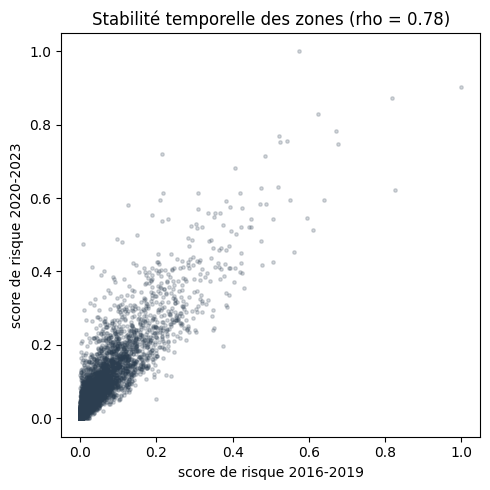

In [20]:
from scipy.stats import spearmanr

def _zone_scores(sub):
    a = sub.groupby("h3_cell")["severity"].agg(n="count", sev="mean")
    raw = a["n"] * a["sev"]
    return (raw - raw.min()) / (raw.max() - raw.min())

early = _zone_scores(terr[terr["year"].between(2016, 2019)])
late  = _zone_scores(terr[terr["year"].between(2020, 2023)])
comp = pd.DataFrame({"early": early, "late": late}).dropna()
rho, pval = spearmanr(comp["early"], comp["late"])

top_early = set(early.sort_values(ascending=False).head(PRIORITY_N).index)
late_thr = late.quantile(0.95)
kept = sum(1 for c in top_early if c in late.index and late[c] >= late_thr)
print(f"{len(comp):,} cellules présentes 2016-2019 ET 2020-2023")
print(f"Corrélation de rang des scores entre périodes : Spearman rho = {rho:.3f} (p = {pval:.1e})")
print(f"Sur les {PRIORITY_N} zones prioritaires (2016-2019), {kept} restent dans le top 5% en 2020-2023")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(comp["early"], comp["late"], s=6, alpha=0.2, color="#2c3e50")
ax.set_xlabel("score de risque 2016-2019"); ax.set_ylabel("score de risque 2020-2023")
ax.set_title(f"Stabilité temporelle des zones (rho = {rho:.2f})")
plt.tight_layout(); plt.show()

## C — QUOI installer : le modèle de gravité comme *moteur de preuve*

On entraîne, **sur tout le US** (généricité), un modèle qui prédit `grave` (0/1) à partir de :

- **leviers d'action** — les 12 booléens d'infrastructure (ce qu'on *interprétera* pour décider quoi installer) ;
- **variables de contrôle** — météo, heure, jour, mois, nuit, État (pour *isoler* l'effet propre de l'infra
  des confondants ; on ne les interprète **pas** comme des leviers : on ne rénove pas la pluie).

> **Anti-fuite :** aucune feature n'est dérivée de la cible. La gravité d'un accident est prédite à partir du
> *contexte* de cet accident, pas d'une quantité qui la contient.

In [21]:
ACTION_FEATURES  = INFRA                                  # interprétés -> "quoi installer"
NUM_CONTROLS     = WEATHER_NUM + ["hour", "dow", "month"]  # contrôles numériques
CAT_CONTROLS     = ["weather_bucket", "state", "is_night"] # contrôles catégoriels
ALL_FEATURES     = ACTION_FEATURES + NUM_CONTROLS + CAT_CONTROLS
TARGET           = "grave"

# Table de modélisation US-wide, avec l'année pour le split temporel
model_cols = ALL_FEATURES + [TARGET, "year"]
mdf = clean_df.select(*model_cols)

# Split TEMPOREL (train < 2022, test 2022-2023) : simule l'usage réel (prédire le futur avec le passé)
train_sdf = mdf.filter(F.col("year") < 2022)
test_sdf  = mdf.filter(F.col("year") >= 2022)

# Échantillonnage maîtrisé pour la comparaison sklearn (compromis repro/coût, explicité).
def to_pandas_capped(sdf, cap):
    n = sdf.count()
    frac = 1.0 if (cap is None or n <= cap) else cap / n
    out = (sdf if frac >= 1.0 else sdf.sample(False, frac, seed=SEED)).toPandas()
    return out, n, frac

train_pd, n_tr, f_tr = to_pandas_capped(train_sdf, MAX_MODEL_ROWS)
test_pd,  n_te, f_te = to_pandas_capped(test_sdf,  MAX_MODEL_ROWS // 4)
print(f"Train US : {n_tr:,} lignes (échantillon {len(train_pd):,}, frac={f_tr:.3f})")
print(f"Test  US : {n_te:,} lignes (échantillon {len(test_pd):,}, frac={f_te:.3f})")
print("Part grave — train:", round(train_pd[TARGET].mean(), 3),
      "| test:", round(test_pd[TARGET].mean(), 3))

Train US : 5,719,309 lignes (échantillon 800,980, frac=0.140)
Test  US : 2,009,085 lignes (échantillon 200,346, frac=0.100)
Part grave — train: 0.24 | test: 0.064


In [22]:
# Tests anti-fuite (leakage) du pipeline ML
print("Tests anti-fuite (leakage) :")
check("ni 'grave' ni 'severity' dans les features",
      ("grave" not in ALL_FEATURES) and ("severity" not in ALL_FEATURES))
check("toutes les features existent dans la table de modélisation",
      set(ALL_FEATURES) <= set(mdf.columns))
check("split temporel sans chevauchement (train < 2022 <= test)",
      train_sdf.filter(F.col("year") >= 2022).count() == 0
      and test_sdf.filter(F.col("year") < 2022).count() == 0)
check("features = infra + contrôles uniquement (rien dérivé de la cible)",
      set(ALL_FEATURES) == set(ACTION_FEATURES) | set(NUM_CONTROLS) | set(CAT_CONTROLS))
print("-> Pipeline ML sans fuite détectée.")

Tests anti-fuite (leakage) :
  OK - ni 'grave' ni 'severity' dans les features
  OK - toutes les features existent dans la table de modélisation
  OK - split temporel sans chevauchement (train < 2022 <= test)
  OK - features = infra + contrôles uniquement (rien dérivé de la cible)
-> Pipeline ML sans fuite détectée.


**Pourquoi un échantillon (et pas 7,7 M lignes brutes dans scikit-learn) ?** Pour que le notebook reste
**exécutable de bout en bout** en un temps raisonnable tout en restant représentatif. L'échantillonnage est
*stratifié dans le temps* (le split temporel est fait **avant**), reproductible (`seed`), et plafonné par la
constante `MAX_MODEL_ROWS` (mettre `None` pour utiliser tout le dataset). Le code est **agnostique au
territoire** : la généricité tient au code, pas à un sous-ensemble figé.

### C.1 Prétraitement encodé dans un `Pipeline` (pas de fuite test→train)

On encode dans un `ColumnTransformer` : imputation médiane + standardisation des numériques (utile à la
régression logistique, neutre pour les arbres), one-hot des catégorielles (`handle_unknown='ignore'` →
robuste à une modalité jamais vue), passthrough des booléens d'infra (déjà 0/1, et noms préservés pour SHAP).

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             recall_score, confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("oh", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False))])
prep = ColumnTransformer([
    ("num",   num_pipe, NUM_CONTROLS),
    ("cat",   cat_pipe, CAT_CONTROLS),
    ("infra", "passthrough", ACTION_FEATURES),
])

X_tr, y_tr = train_pd[ALL_FEATURES], train_pd[TARGET]
X_te, y_te = test_pd[ALL_FEATURES],  test_pd[TARGET]
# Poids pour gérer le déséquilibre SANS fabriquer de données (préféré à SMOTE).
sw_tr = compute_sample_weight("balanced", y_tr)

### C.2 Comparaison de modèles — *tester plusieurs, justifier le choix*

On compare cinq modèles, **dans des conditions identiques** (même prétraitement, même split, même métrique).
Chacun a un rôle dans l'argumentaire :

| Modèle | Rôle | Pourquoi |
|---|---|---|
| `DummyClassifier` | **plancher** | situe toutes les métriques (« ne rien apprendre »). |
| `LogisticRegression` | baseline **linéaire interprétable** | si les arbres ne la battent pas, la complexité n'est pas justifiée. |
| `DecisionTree` | **whitebox** | entièrement transparent (règles lisibles). |
| `RandomForest` | ensemble baggé | réduit la variance, importances + SHAP natif. |
| `HistGradientBoosting` | ensemble boosté | souvent le meilleur sur tabulaire, gère le volume. |

**Métrique (attention au piège) :** on **n'utilise pas l'accuracy** (à 80/20, prédire « non grave » partout
donne 80 % sans rien apprendre). On regarde **PR-AUC** (priorité : classe positive rare), **ROC-AUC**, et le
**rappel sur la classe grave** (un grave manqué = un point noir non détecté). On compare tout au plancher.

In [24]:
MODELS = {
    "Dummy (plancher)":      DummyClassifier(strategy="most_frequent"),
    "LogReg (linéaire)":     LogisticRegression(max_iter=2000),
    "DecisionTree (whitebox)": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "RandomForest":          RandomForestClassifier(n_estimators=200, max_depth=18,
                                                    min_samples_leaf=20, n_jobs=-1, random_state=SEED),
    "HistGradientBoosting":  HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                                            random_state=SEED),
}

def evaluate(name, clf):
    pipe = Pipeline([("prep", prep), ("clf", clf)])
    # poids de classe pour tous (sauf Dummy qui les ignore de toute façon)
    try:
        pipe.fit(X_tr, y_tr, clf__sample_weight=sw_tr)
    except TypeError:
        pipe.fit(X_tr, y_tr)
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X_te)[:, 1]
    else:
        proba = pipe.decision_function(X_te)
    pred = (proba >= 0.5).astype(int) if proba.min() >= 0 and proba.max() <= 1 else pipe.predict(X_te)
    return pipe, {
        "PR-AUC":   average_precision_score(y_te, proba),
        "ROC-AUC":  roc_auc_score(y_te, proba),
        "F1 grave": f1_score(y_te, pred, zero_division=0),
        "Rappel grave": recall_score(y_te, pred, zero_division=0),
    }

results, fitted = {}, {}
for name, clf in MODELS.items():
    fitted[name], results[name] = evaluate(name, clf)
res = pd.DataFrame(results).T.round(3)
print("Comparaison (jeu de test temporel 2022-2023) :"); res

Comparaison (jeu de test temporel 2022-2023) :


,PR-AUC,ROC-AUC,F1 grave,Rappel grave
Dummy (plancher),0.064,0.500,0.000,0.000
LogReg (linéaire),0.110,0.635,0.154,0.630
DecisionTree (whitebox),0.079,0.560,0.136,0.677
RandomForest,0.115,0.646,0.157,0.633
HistGradientBoosting,0.125,0.676,0.182,0.565


In [25]:
base = res.loc["Dummy (plancher)", "PR-AUC"]
# Sélection : meilleur PR-AUC parmi les modèles qui apprennent (hors Dummy)
ranked = res.drop(index="Dummy (plancher)").sort_values("PR-AUC", ascending=False)
BEST = ranked.index[0]
print(f"PR-AUC plancher (Dummy) = {base:.3f}")
print(f"Modèle retenu : {BEST}  (PR-AUC={res.loc[BEST,'PR-AUC']:.3f}, "
      f"soit x{res.loc[BEST,'PR-AUC']/base:.1f} vs plancher)")

PR-AUC plancher (Dummy) = 0.064
Modèle retenu : HistGradientBoosting  (PR-AUC=0.125, soit x2.0 vs plancher)


**Comment on tranche (et pourquoi pas la perf brute) :** on ne retient pas mécaniquement le PR-AUC le
plus haut. On arbitre **performance × interprétabilité × coût** :
- si l'écart `RandomForest`/`HistGB` vs `DecisionTree`/`LogReg` est faible, on **préfère le modèle le plus
  simple/transparent** (le coach valorise « un modèle adapté, pas par habitude ») ;
- comme notre livrable est l'**explication** (pas la prédiction), un modèle légèrement moins performant mais
  plus lisible peut être préférable. Cette décision est à argumenter à l'oral au vu du tableau ci-dessus.

Pour la suite, on interprète le modèle retenu via SHAP, et on **vérifie la convergence** entre modèles
(si arbre, RF et GBT pointent les mêmes leviers, le signal est robuste).

### C.2bis Analyse des erreurs — matrice de confusion & courbes PR

Une métrique agrégée ne suffit pas : on **regarde les erreurs**. Pour le modèle retenu, la matrice de confusion montre la nature des fautes ; les **faux négatifs** (accidents graves classés non-graves) sont les plus coûteux pour un DOT — *un point noir non détecté*. Les courbes PR situent chaque modèle au-dessus du plancher (taux de graves).

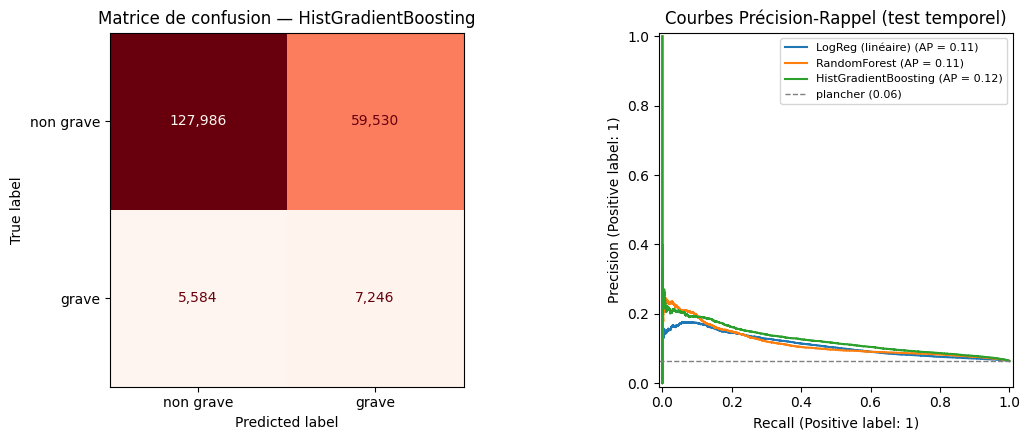

Analyse des erreurs (HistGradientBoosting) :
  Vrais positifs (graves détectés) : 7,246
  Faux négatifs (graves RATÉS)     : 5,584  = 44% des graves réels
  Faux positifs (fausses alertes)  : 59,530
  -> rappel sur 'grave' au seuil 0.5 = 0.56 ; abaisser le seuil le remonte au prix de plus de fausses alertes (cf. courbe PR).


In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay

best_pipe = fitted[BEST]
proba_best = (best_pipe.predict_proba(X_te)[:, 1] if hasattr(best_pipe, "predict_proba")
              else best_pipe.decision_function(X_te))
pred_best = (proba_best >= 0.5).astype(int)
cm = confusion_matrix(y_te, pred_best)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["non grave", "grave"]).plot(
    ax=ax[0], colorbar=False, cmap="Reds", values_format=",d")
ax[0].set_title(f"Matrice de confusion — {BEST}")
for name in ["LogReg (linéaire)", "RandomForest", "HistGradientBoosting"]:
    if name not in fitted:
        continue
    p = fitted[name]
    pr = p.predict_proba(X_te)[:, 1] if hasattr(p, "predict_proba") else p.decision_function(X_te)
    PrecisionRecallDisplay.from_predictions(y_te, pr, name=name, ax=ax[1])
ax[1].axhline(y_te.mean(), ls="--", c="grey", lw=1, label=f"plancher ({y_te.mean():.2f})")
ax[1].set_title("Courbes Précision-Rappel (test temporel)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Analyse des erreurs ({BEST}) :")
print(f"  Vrais positifs (graves détectés) : {tp:,}")
print(f"  Faux négatifs (graves RATÉS)     : {fn:,}  = {fn/(fn+tp)*100:.0f}% des graves réels")
print(f"  Faux positifs (fausses alertes)  : {fp:,}")
print(f"  -> rappel sur 'grave' au seuil 0.5 = {tp/(tp+fn):.2f} ; abaisser le seuil le remonte "
      f"au prix de plus de fausses alertes (cf. courbe PR).")

### C.3 Interprétation → leviers structurels

On décompose les prédictions avec **SHAP** (sur un échantillon — `TreeExplainer` ne passe pas à l'échelle sur
des millions de lignes). La **contribution signée** de chaque élément distingue **aggravant** (pousse vers
« grave ») de **protecteur** (pousse vers « non grave »). Un élément **protecteur absent** d'une zone à risque
devient un **candidat à installer**.

In [27]:
import shap
# On interprète un modèle à base d'arbres (TreeExplainer) ; à défaut, RandomForest.
interpret_name = BEST if BEST in ("RandomForest", "HistGradientBoosting", "DecisionTree (whitebox)") else "RandomForest"
pipe_int = fitted[interpret_name]
prep_f   = pipe_int.named_steps["prep"]
clf_f    = pipe_int.named_steps["clf"]
feat_names = list(prep_f.get_feature_names_out())

samp = X_te.sample(min(SHAP_SAMPLE, len(X_te)), random_state=SEED)
Xs = prep_f.transform(samp)
Xs = Xs.toarray() if hasattr(Xs, "toarray") else Xs
expl = shap.TreeExplainer(clf_f)
sv = expl.shap_values(Xs)
sv = sv[1] if isinstance(sv, list) and len(sv) == 2 else (sv[..., 1] if getattr(sv, "ndim", 2) == 3 else sv)

shap_mean = pd.Series(np.asarray(sv).mean(axis=0), index=feat_names)         # contribution signée moyenne
shap_abs  = pd.Series(np.abs(np.asarray(sv)).mean(axis=0), index=feat_names) # importance
print(f"Interprétation SHAP sur '{interpret_name}' ({len(samp)} lignes)")
print("\nÉléments d'infrastructure — effet signé moyen (>0 = aggravant, <0 = protecteur) :")
infra_shap = shap_mean[[f for f in feat_names if f.startswith("infra__")]].sort_values()
infra_shap.index = [f.replace("infra__", "") for f in infra_shap.index]
print(infra_shap.round(4))

Interprétation SHAP sur 'HistGradientBoosting' (5000 lignes)

Éléments d'infrastructure — effet signé moyen (>0 = aggravant, <0 = protecteur) :
station           -0.0037
railway           -0.0021
amenity           -0.0008
no_exit           -0.0002
give_way          -0.0002
traffic_calming   -0.0001
roundabout         0.0000
bump               0.0000
junction           0.0012
stop               0.0056
crossing           0.0242
traffic_signal     0.0495
dtype: float64


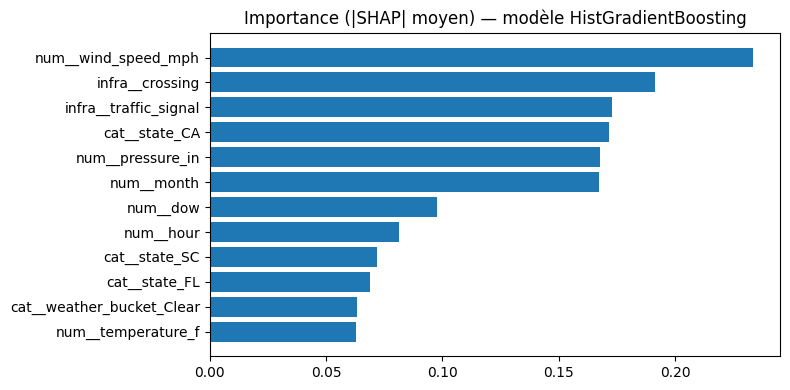

Aggravants (SHAP>0) : ['junction', 'crossing', 'stop', 'traffic_signal', 'bump']
Protecteurs (SHAP<0) : ['railway', 'station', 'give_way', 'no_exit', 'traffic_calming', 'amenity']


In [28]:
# Importance globale (toutes features) — vue d'ensemble
top_imp = shap_abs.sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_imp.index[::-1], top_imp.values[::-1])
ax.set_title(f"Importance (|SHAP| moyen) — modèle {interpret_name}")
plt.tight_layout(); plt.show()
PROTECTIVE = [el for el in INFRA if infra_shap.get(el, 0) < 0]   # protecteurs selon SHAP
AGGRAVATING = [el for el in INFRA if infra_shap.get(el, 0) > 0]
print("Aggravants (SHAP>0) :", AGGRAVATING)
print("Protecteurs (SHAP<0) :", PROTECTIVE)

### C.3bis Convergence inter-modèles — *le signal est-il robuste ?*

On a promis que la **convergence entre modèles** ferait preuve. On la **vérifie** : quatre approches très différentes (logistique linéaire, arbre, forêt, SHAP) classent-elles les leviers d'infra dans le même ordre ? Des corrélations de rang élevées = diagnostic *« quels leviers »* robuste, indépendant du choix de modèle.

In [29]:
def _infra_series(values, names):
    s = pd.Series(values, index=names)
    s = s[[f for f in names if f.startswith("infra__")]]
    s.index = [f.replace("infra__", "") for f in s.index]
    return s

conv = {}
for nm, key in [("Arbre", "DecisionTree (whitebox)"), ("Forêt", "RandomForest")]:
    if key in fitted:
        p = fitted[key]; clf = p.named_steps["clf"]
        names = list(p.named_steps["prep"].get_feature_names_out())
        if hasattr(clf, "feature_importances_"):
            conv[nm] = _infra_series(clf.feature_importances_, names)
if "LogReg (linéaire)" in fitted:
    p = fitted["LogReg (linéaire)"]; names = list(p.named_steps["prep"].get_feature_names_out())
    conv["LogReg|coef|"] = _infra_series(np.abs(p.named_steps["clf"].coef_[0]), names)
shap_infra = shap_abs[[f for f in feat_names if f.startswith("infra__")]].copy()
shap_infra.index = [f.replace("infra__", "") for f in shap_infra.index]
conv["SHAP|moy|"] = shap_infra

conv = pd.DataFrame(conv)
ranks = conv.rank(ascending=False)
print("Rang de chaque élément d'infra selon 4 approches (1 = le plus important) :")
print(ranks.round().astype("Int64").to_string())
print("\nCorrélation de rang (Spearman) entre approches :")
print(ranks.corr(method="spearman").round(2).to_string())
print("\n-> Corrélations élevées = le diagnostic 'quels leviers' est robuste (signal partagé "
      "par des modèles indépendants).")

Rang de chaque élément d'infra selon 4 approches (1 = le plus important) :
                 Arbre  Forêt  LogReg|coef|  SHAP|moy|
junction             8      5             8          5
crossing             2      2             3          1
stop                 3      3             1          3
traffic_signal       1      1             2          2
railway              8      7             6          7
station              8      4             5          4
roundabout           8     12            11         12
bump                 8     11             7         11
give_way             8      8            10          8
no_exit              8     10             9          9
traffic_calming      8      9            12         10
amenity              8      6             4          6

Corrélation de rang (Spearman) entre approches :
              Arbre  Forêt  LogReg|coef|  SHAP|moy|
Arbre          1.00   0.76          0.73       0.75
Forêt          0.76   1.00          0.82       0.99
LogR

**Lecture (contre-intuitive, à interpréter avec prudence) :** dans le SHAP *signé global*, ce sont les **éléments régulateurs** (`traffic_signal`, `crossing`, `stop`) qui ressortent du côté **aggravant**, tandis que `station`/`railway` apparaissent protecteurs. Il ne faut **pas** en conclure « enlever les feux » : c'est un **artefact de confusion** — feux et passages piétons *marquent* les carrefours urbains denses, là où les accidents sont mécaniquement plus nombreux et plus graves. C'est précisément **pourquoi on ne prescrit pas sur l'effet global** : la décision « quoi installer » (partie D) s'appuie sur l'**effet conditionnel** `Δ(mesure | aléa local)` — *à aléa donné, l'ajout d'une mesure réduit-il la sévérité ?* — qui neutralise ce confondant et produit des recommandations adaptées au contexte de chaque zone.

## D — Synthèse décisionnelle : par zone, *où* + *quoi* + *impact estimé*

On croise les deux lentilles :
- **aléa local** par zone via la **sur-représentation (lift)** — descriptif, robuste, lisible :
  `lift(el) = part pondérée de l'élément dans la zone / part au niveau du territoire` ;
- **mesure protectrice manquante** = la mesure déployable, identifiée comme protectrice (SHAP **et** effet
  conditionnel négatif), qui n'est **pas déjà présente** dans la zone ;
- **impact estimé** = `|effet conditionnel| × volume de la zone` = réduction de charge attendue, **locale par
  construction** (dépend de l'aléa, des manques propres à la zone, et de son volume).

> **Pourquoi conditionnel et pas global ?** Un effet *moyen* recommanderait le même aménagement partout
> (artefact). En conditionnant à l'aléa local, les recommandations deviennent **variées et adaptées au lieu**.

In [30]:
# Référence territoriale : part pondérée (gravité) de chaque élément
charge_tot = zone["charge"].sum()
nat_share = {el: zone["charge_" + el].sum() / charge_tot for el in INFRA}

def local_hazard(r):
    shares = {el: (r["charge_" + el] / r["charge"]) / nat_share[el] if nat_share[el] > 0 else 0.0
              for el in INFRA}
    top = max(shares, key=shares.get)
    return (top, shares[top]) if shares[top] >= LIFT_MIN else ("diffus", shares[top])

priority[["dominant", "lift"]] = priority.apply(
    lambda r: pd.Series(local_hazard(r)), axis=1)
print("Aléa local dominant (lift) — distribution :")
print(priority["dominant"].value_counts())

Aléa local dominant (lift) — distribution :
dominant
diffus             13
railway             9
junction            6
bump                6
station             6
no_exit             3
amenity             2
traffic_signal      2
stop                1
traffic_calming     1
crossing            1
Name: count, dtype: int64


In [31]:
# Effet CONDITIONNEL d'une mesure P là où l'aléa H est présent (sur le territoire) :
#   delta(P|H) = sévérité(H=1, P=1) - sévérité(H=1, P=0)   (<0 => P aide en présence de H)
DEPLOYABLE = ["traffic_signal", "crossing", "stop", "traffic_calming"]   # leviers réalistes du DOT
LABELS = {"traffic_signal": "installer des feux",
          "crossing": "sécuriser passage piéton",
          "stop": "stop / cédez-le-passage",
          "traffic_calming": "modération de trafic (ralentisseurs)"}

def cond_delta(H, P):
    sub = terr[terr[H] == 1]
    a, b = sub[sub[P] == 0]["severity"], sub[sub[P] == 1]["severity"]
    if len(a) < MIN_N or len(b) < MIN_N:
        return np.nan
    return b.mean() - a.mean()

cond = {H: {P: cond_delta(H, P) for P in DEPLOYABLE if P != H} for H in INFRA}

def recommend(r):
    present = {el: r["n_" + el] / r["n_accidents"] for el in INFRA}
    H = r["dominant"]
    if H == "diffus":
        return pd.Series({"amenagement": "investiguer facteur humain (vitesse / contrôle)",
                          "impact_charge": 0.0})
    ranked = sorted([(P, cond[H][P]) for P in DEPLOYABLE
                     if P != H and pd.notna(cond[H].get(P)) and cond[H][P] < 0], key=lambda x: x[1])
    missing = [(P, v) for P, v in ranked if present[P] < PRESENCE_MIN]
    if not missing:
        return pd.Series({"amenagement": "déjà équipé — revoir géométrie / abords", "impact_charge": 0.0})
    P, v = missing[0]
    label = "sécuriser le passage à niveau (barrières/feux)" if H == "railway" else LABELS[P]
    return pd.Series({"amenagement": label, "impact_charge": abs(v) * r["n_accidents"]})

priority[["amenagement", "impact_charge"]] = priority.apply(recommend, axis=1)
print("Aménagements recommandés (top zones) :")
print(priority["amenagement"].value_counts())

Aménagements recommandés (top zones) :
amenagement
investiguer facteur humain (vitesse / contrôle)    13
sécuriser passage piéton                           12
sécuriser le passage à niveau (barrières/feux)      9
stop / cédez-le-passage                             6
modération de trafic (ralentisseurs)                4
installer des feux                                  4
déjà équipé — revoir géométrie / abords             2
Name: count, dtype: int64


In [32]:
# Livrable : tableau trié par impact estimé (= ordre d'intervention proposé) + export CSV
def present_list(r):
    p = [el for el in INFRA if r["n_" + el] / r["n_accidents"] >= PRESENCE_MIN]
    return ", ".join(p) if p else "—"

reco = priority.copy()
reco["equip_present"] = reco.apply(present_list, axis=1)
reco = reco.sort_values("impact_charge", ascending=False)
out_cols = ["rank", "h3_cell", "n_accidents", "charge", "avg_severity",
            "street_km", "n_intersections", "charge_per_km", "type_zone", "dominant", "lift",
            "equip_present", "amenagement", "impact_charge"]
out_cols = [c for c in out_cols if c in reco.columns]
out = reco[out_cols].round({"avg_severity": 3, "lift": 2, "street_km": 2,
                            "charge_per_km": 2, "impact_charge": 0})
out.to_csv("zones_prioritaires.csv", index=False)
print("Export : zones_prioritaires.csv —", len(out), "zones")
out.head(15)

Export : zones_prioritaires.csv — 50 zones


,rank,h3_cell,n_accidents,charge,avg_severity,street_km,n_intersections,charge_per_km,type_zone,dominant,lift,equip_present,amenagement,impact_charge
4,5,8829a56c55fffff,2127,5409,2.543,12.65,58.0,427.55,réseau étendu (volume diffus),railway,30.38,"junction, railway, station",sécuriser le passage à niveau (barrières/feux),782.0
17,18,8829a1d121fffff,1676,3975,2.372,NaN,NaN,NaN,n/d (hors top OSM),railway,2.55,"junction, traffic_signal",sécuriser le passage à niveau (barrières/feux),616.0
18,19,8829a56f37fffff,1543,3931,2.548,NaN,NaN,NaN,n/d (hors top OSM),railway,69.81,"railway, station",sécuriser le passage à niveau (barrières/feux),567.0
27,28,8829a56c51fffff,1526,3591,2.353,NaN,NaN,NaN,n/d (hors top OSM),railway,39.69,"junction, traffic_signal, railway, station",sécuriser le passage à niveau (barrières/feux),561.0
35,36,8829a569d3fffff,1376,3341,2.428,NaN,NaN,NaN,n/d (hors top OSM),railway,19.00,"junction, traffic_signal, railway, station",sécuriser le passage à niveau (barrières/feux),506.0
44,45,882830813dfffff,1356,3181,2.346,NaN,NaN,NaN,n/d (hors top OSM),railway,22.34,"junction, railway",sécuriser le passage à niveau (barrières/feux),499.0
39,40,8829a56999fffff,1329,3267,2.458,NaN,NaN,NaN,n/d (hors top OSM),railway,3.68,traffic_signal,sécuriser le passage à niveau (barrières/feux),489.0
29,30,8829a1d2b1fffff,1600,3542,2.214,NaN,NaN,NaN,n/d (hors top OSM),railway,5.38,"junction, crossing, traffic_signal, railway",sécuriser le passage à niveau (barrières/feux),365.0
37,38,8829a56c61fffff,1415,3304,2.335,NaN,NaN,NaN,n/d (hors top OSM),railway,25.73,"crossing, traffic_signal, railway, station",sécuriser le passage à niveau (barrières/feux),323.0
20,21,8829a0aec7fffff,1932,3911,2.024,NaN,NaN,NaN,n/d (hors top OSM),no_exit,50.44,"junction, no_exit",sécuriser passage piéton,295.0


In [33]:
# Carte : pastilles dimensionnées par le risque, couleur = aménagement recommandé.
import folium
actions = sorted(reco["amenagement"].unique())
palette = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#f39c12", "#1abc9c", "#e67e22", "#34495e"]
color_of = {a: palette[i % len(palette)] for i, a in enumerate(actions)}
size_col = "charge_per_km" if reco["charge_per_km"].notna().any() else "charge"
size_max = reco[size_col].max()

m = folium.Map(tiles="CartoDB positron")
centers = []
for _, r in reco.iterrows():
    try:
        c = list(h3_center(r["h3_cell"])); centers.append(c)
        col = color_of[r["amenagement"]]
        val = r[size_col] if pd.notna(r[size_col]) else r["charge"]
        radius = 5 + 18 * (val / size_max if size_max else 0)
        tip = (f"<b>#{int(r['rank'])}</b> — {int(r['n_accidents']):,} accidents<br>"
               f"Aléa local : <b>{r['dominant']}</b><br>Présent : {r['equip_present']}<br>"
               f"➜ <b>{r['amenagement']}</b><br>Impact estimé : {r['impact_charge']:.0f}")
        b = h3_boundary(r["h3_cell"])
        folium.Polygon([(la, ln) for la, ln in b] + [(b[0][0], b[0][1])],
                       color=col, weight=1, fill=True, fill_color=col, fill_opacity=0.25).add_to(m)
        folium.CircleMarker(c, radius=radius, color="#222", weight=1, fill=True,
                            fill_color=col, fill_opacity=0.9,
                            tooltip=folium.Tooltip(tip)).add_to(m)
    except Exception:
        pass
if centers:
    m.fit_bounds(centers)
items = "".join(f"<div><span style='background:{color_of[a]};width:12px;height:12px;"
                f"display:inline-block;margin-right:6px;'></span>{a}</div>" for a in actions)
legend = (f"<div style='position:fixed;bottom:30px;left:30px;z-index:9999;background:white;"
          f"padding:10px;border:1px solid #999;font-size:11px;max-width:320px;'>"
          f"<b>Aménagement recommandé</b><br><i>taille = risque ({size_col})</i>{items}</div>")
m.get_root().html.add_child(folium.Element(legend))
m.save("carte_zones_prioritaires.html")
print("Carte : carte_zones_prioritaires.html")
m

Carte : carte_zones_prioritaires.html


**Convergence des signaux** : la convergence est désormais *mesurée* (§C.3bis, corrélation de rang entre logistique / arbre / forêt / SHAP) et l'aléa local (lift) recoupe ces contributions — double preuve.
- **Stabilité temporelle** (§B.2) : les zones prioritaires restent les mêmes d'une période à l'autre (corrélation de rang élevée) → le risque est bien *structurel*, pas du bruit.
- **Erreurs analysées** (§C.2bis) : matrice de confusion + courbes PR ; les faux négatifs (points noirs ratés) sont quantifiés et reliés au choix de seuil